# 04 — Drift Analysis

Computes the **temporal diagnostic profile** for each window pair (A, B) across all
supported model types, then renders a combined dashboard. Reflects the methodology
described in the thesis (no drift ratio; per-window baselines reported separately
for A and B; global attribution drift restricted to SHAP).

**Model types:** `MODEL_TYPES = ['xgboost', 'logreg', 'mlp_plr']`
Artifacts are read from `data/models/{model_type}/`, `data/shap/{model_type}/`, and
`data/lime/{model_type}/`.

**Input:** `data/processed/`, `data/windows/`, `data/models/{model_type}/`, `data/shap/{model_type}/`, `data/lime/{model_type}/`
**Output per model type:** `data/results/{model_type}/drift_metrics.csv`
**Combined outputs:** `data/results/combined/drift_metrics_combined.csv`, `data/results/combined/drift_dashboard_*.png`

---

| Metric | Symbol | XGBoost (SHAP) | XGBoost / MLP-PLR (LIME) | LR (coef ref) |
|---|---|---|---|---|
| Covariate drift | Δ_X | ✓ | ✓ | ✓ |
| Target drift | Δ_Y | ✓ | ✓ | ✓ |
| Performance change | Δ_perf | ✓ | ✓ | ✓ |
| Local dynamic drift (cosine) | loc_cos | ✓ (SHAP) | ✓ (LIME) | — |
| Local dynamic drift (RBO) | loc_rbo | ✓ (SHAP) | ✓ (LIME) | — |
| Within-window baseline (cosine) — A | base_cos_A | ✓ | ✓ | ✓ |
| Within-window baseline (cosine) — B | base_cos_B | ✓ | ✓ | ✓ |
| Within-window baseline (RBO) — A | base_rbo_A | ✓ | ✓ | ✓ |
| Within-window baseline (RBO) — B | base_rbo_B | ✓ | ✓ | ✓ |
| Global attribution drift | global_rbo | ✓ (SHAP only) | — | — |
| Explainer stochasticity | `stoch_cos_A/B`, `stoch_rbo_A/B`, `stoch_cos`, `stoch_rbo`  | ✓ | ✓ | N/A |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


> **Setup note:** this notebook requires the `rbo` package for rank-biased overlap metrics (§3.5, §3.8).  
> If not already installed, run: `pip install rbo`

In [2]:
%pip install rbo --no-deps

In [3]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
from itertools import combinations
import rbo

WORKSPACE  = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
PROC_DIR   = WORKSPACE / 'data' / 'processed'
WIN_DIR    = WORKSPACE / 'data' / 'windows'

# ── Per-model-type base directories ───────────────────────────────────
MODEL_DIR_BASE   = WORKSPACE / 'data' / 'models'
SHAP_DIR_BASE    = WORKSPACE / 'data' / 'shap'
LIME_DIR_BASE    = WORKSPACE / 'data' / 'lime'
RESULTS_DIR_BASE = WORKSPACE / 'data' / 'results'

# Aliases used by downstream cells
SHAP_DIR    = SHAP_DIR_BASE / 'xgboost'
RESULTS_DIR = RESULTS_DIR_BASE

COMBINED_DIR = RESULTS_DIR_BASE / 'combined'
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

# ── What to compute ────────────────────────────────────────────────────
MODEL_TYPES = ['xgboost', 'logreg', 'mlp_plr']
EXPLAINERS  = ['shap', 'lime']   # per-row attribution sources to iterate over
                                 # LR emits a 'coef' row handled outside this list

RBO_P = 0.9

print('Imports OK')
print(f'MODEL_TYPES: {MODEL_TYPES}')
print(f'EXPLAINERS : {EXPLAINERS}')

Imports OK
MODEL_TYPES: ['xgboost', 'logreg', 'mlp_plr']
EXPLAINERS : ['shap', 'lime']


In [4]:
X_df = pd.read_parquet(PROC_DIR / 'X.parquet')
Y    = np.load(PROC_DIR / 'Y.npy').astype(np.int8)

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)

feature_names     = feature_names_json['all']
num_feature_names = feature_names_json['num']

assert list(X_df.columns) == feature_names, (
    "X.parquet column order does not match feature_names['all']. "
    "This would misalign drift metrics, feature rankings, and coefficient plots."
)

X = X_df.values.astype(np.float32)

# Column indices of numeric / binary features in X (column order matches feature_names)
num_col_idx = [feature_names.index(fn) for fn in num_feature_names]
bin_col_idx = [i for i in range(len(feature_names)) if i not in set(num_col_idx)]

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']
n_features = len(feature_names)

assert X.shape[0] == Y.shape[0], "X and Y have inconsistent numbers of rows."
assert X.shape[1] == n_features, "X column count does not match feature_names['all']."
assert len(set(feature_names)) == len(feature_names), "feature_names contains duplicates."
assert len(set(num_col_idx) & set(bin_col_idx)) == 0, "Numeric and binary indices overlap."
assert len(num_col_idx) + len(bin_col_idx) == n_features, (
    "Numeric/binary feature partition does not cover all features."
)
assert len(pairs) > 0, "No rolling-window pairs found in window_config.json."

print(f'X: {X.shape}, features: {n_features}, R={R}, pairs: {len(pairs)}')
print(f'  Numeric: {len(num_col_idx)}, Binary: {len(bin_col_idx)}')

X: (160057, 119), features: 119, R=8, pairs: 2
  Numeric: 113, Binary: 6


## Distance and RBO helper functions

In [5]:
def cosine_distance(u: np.ndarray, v: np.ndarray) -> float:
    """d_cos(u,v) = 1 - cosine_similarity(u,v).
    Both-zero → 0.0; one-zero one-nonzero → np.nan (excluded by nanmedian aggregation).
    """
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u < 1e-12 and norm_v < 1e-12:
        return 0.0
    if norm_u < 1e-12 or norm_v < 1e-12:
        # One attribution vector is exactly zero; the other is not.
        # Not a meaningful distance — marked nan and dropped during aggregation.
        return np.nan
    return float(1.0 - np.dot(u, v) / (norm_u * norm_v))


def rbo_score_local(l1, l2, p=0.9):
    """Simple RBO implementation as fallback."""
    if not l1 or not l2: return 0.0
    n = min(len(l1), len(l2))
    s1, s2 = set(), set()
    agreement = 0.0
    res = 0.0
    for i in range(n):
        s1.add(l1[i])
        s2.add(l2[i])
        agreement = len(s1.intersection(s2)) / (i + 1)
        res += agreement * (p ** i)
    return res * (1 - p)


def rbo_distance(u: np.ndarray, v: np.ndarray, p: float = RBO_P) -> float:
    """
    d_rbo(u, v) = 1 - RBO(rank(u), rank(v)).
    Features are ranked by decreasing absolute attribution.
    Both-zero → 0.0; one-zero one-nonzero → np.nan.
    """
    u_zero = np.all(np.abs(u) < 1e-12)
    v_zero = np.all(np.abs(v) < 1e-12)
    if u_zero and v_zero:
        return 0.0
    if u_zero or v_zero:
        return np.nan
    rank_u = list(np.argsort(-np.abs(u)))
    rank_v = list(np.argsort(-np.abs(v)))
    score = rbo.RankingSimilarity(rank_u, rank_v).rbo(p=p)
    return float(1.0 - score)


def instance_dynamic_drift(
    phi_A: np.ndarray,  # (R, p) — R attribution vectors from window A
    phi_B: np.ndarray,  # (R, p) — R attribution vectors from window B
    dist_fn,
) -> float:
    """
    δ_dyn(x; d) = mean over all R×R cross-window pairs of d(φ_A^{(r)}, φ_B^{(s)}).
    """
    dists = []
    for r in range(R):
        for s in range(R):
            dists.append(dist_fn(phi_A[r], phi_B[s]))
    return float(np.nanmean(dists))


def instance_baseline_instability(
    phi: np.ndarray,  # (R, p) — R attribution vectors from same window
    dist_fn,
) -> float:
    """
    δ^{base}(x; d) = median over all r < r' pairs of d(φ^{(r)}, φ^{(r')}).
    """
    dists = []
    for r, r2 in combinations(range(R), 2):
        dists.append(dist_fn(phi[r], phi[r2]))
    return float(np.nanmedian(dists)) if dists else 0.0


def rbo_global_drift(
    phi_bar_A: np.ndarray,  # (|F|, p)
    phi_bar_B: np.ndarray,  # (|F|, p)
    p: float = RBO_P,
) -> float:
    """
    Δ_E^{glob}: 1 − RBO(rank(g_A), rank(g_B)) where g(j) = mean_x |φ̄_j(x)|.
    """
    g_A = np.abs(phi_bar_A).mean(axis=0)
    g_B = np.abs(phi_bar_B).mean(axis=0)
    rank_A = list(np.argsort(-g_A))
    rank_B = list(np.argsort(-g_B))
    score = rbo.RankingSimilarity(rank_A, rank_B).rbo(p=p)
    return float(1.0 - score)

def explainer_stochasticity_from_runs(phi_runs: np.ndarray) -> dict:
    """
    Compute explainer-only stochasticity from repeated explainer runs.

    phi_runs shape:
        (Q, n_instances, n_features)

    Aggregation mirrors the baseline-instability logic:
    - pairwise distances between repeated explainer runs;
    - median over run pairs per instance;
    - median over instances.
    """
    phi_runs = np.asarray(phi_runs)
    assert phi_runs.ndim == 3, f'Expected (Q, n, p), got {phi_runs.shape}'

    Q, n, _ = phi_runs.shape

    if Q == 1:
        return {
            'stoch_cos': 0.0,
            'stoch_rbo': 0.0,
        }

    assert Q >= 2, 'Need at least two stochasticity runs or Q=1 deterministic run.'

    inst_cos = []
    inst_rbo = []

    for i in range(n):
        cos_vals = []
        rbo_vals = []

        for q1, q2 in combinations(range(Q), 2):
            u = phi_runs[q1, i]
            v = phi_runs[q2, i]

            cos_vals.append(cosine_distance(u, v))
            rbo_vals.append(rbo_distance(u, v))

        inst_cos.append(np.nanmedian(cos_vals))
        inst_rbo.append(np.nanmedian(rbo_vals))

    return {
        'stoch_cos': float(np.nanmedian(inst_cos)),
        'stoch_rbo': float(np.nanmedian(inst_rbo)),
    }


def load_explainer_stochasticity(attr_dir: Path,
                                 explainer_name: str) -> dict:
    """
    Load raw stochasticity tensors and compute cosine/RBO diagnostics.

    Returns:
        stoch_cos_A, stoch_cos_B, stoch_rbo_A, stoch_rbo_B,
        stoch_cos, stoch_rbo, explainer_is_deterministic, stoch_n_runs
    """
    stoch_json_path = attr_dir / 'stochasticity.json'

    out = {
        'stoch_cos_A': np.nan,
        'stoch_cos_B': np.nan,
        'stoch_rbo_A': np.nan,
        'stoch_rbo_B': np.nan,
        'stoch_cos': np.nan,
        'stoch_rbo': np.nan,
        'stoch_n_runs': np.nan,
        'explainer_is_deterministic': np.nan,

        # Legacy columns kept so old summary/plot code does not crash.
        'explainer_stoch_max_abs': np.nan,
        'explainer_stoch_median_abs': np.nan,
        'shap_stochasticity': np.nan,
    }

    if not stoch_json_path.exists():
        return out

    with open(stoch_json_path) as f:
        meta = json.load(f)

    out['stoch_n_runs'] = int(meta.get('n_runs', np.nan))
    out['explainer_is_deterministic'] = bool(meta.get('is_deterministic_runs', False))

    if explainer_name == 'shap':
        path_A = attr_dir / 'shap_stoch_A.npy'
        path_B = attr_dir / 'shap_stoch_B.npy'
    elif explainer_name == 'lime':
        path_A = attr_dir / 'lime_stoch_A.npy'
        path_B = attr_dir / 'lime_stoch_B.npy'
    else:
        return out

    if not (path_A.exists() and path_B.exists()):
        return out

    phi_A_runs = np.load(path_A)
    phi_B_runs = np.load(path_B)

    mA = explainer_stochasticity_from_runs(phi_A_runs)
    mB = explainer_stochasticity_from_runs(phi_B_runs)

    out['stoch_cos_A'] = mA['stoch_cos']
    out['stoch_cos_B'] = mB['stoch_cos']
    out['stoch_rbo_A'] = mA['stoch_rbo']
    out['stoch_rbo_B'] = mB['stoch_rbo']

    # Conservative single marker for plotting.
    out['stoch_cos'] = float(np.nanmax([out['stoch_cos_A'], out['stoch_cos_B']]))
    out['stoch_rbo'] = float(np.nanmax([out['stoch_rbo_A'], out['stoch_rbo_B']]))

    return out


def lr_coef_to_reference_basis(pipe,
                               reference_scaler: StandardScaler,
                               num_col_idx: list[int]) -> np.ndarray:
    """
    Convert a fitted LR pipeline's coefficient vector into the common pair-level
    reference basis.

    Numeric features are expressed per reference-window standard deviation.
    Binary features are expressed per raw 0/1 change.
    """
    scaler = pipe.named_steps['scaler']
    model  = pipe.named_steps['model']

    beta_std = model.coef_.ravel().astype(np.float64)

    train_scale = scaler.scale_.astype(np.float64)
    train_scale_safe = np.where(train_scale == 0.0, 1.0, train_scale)

    beta_raw = beta_std / train_scale_safe

    beta_ref = beta_raw.copy()
    ref_scale = reference_scaler.scale_.astype(np.float64)

    for pos_in_ref, j in enumerate(num_col_idx):
        beta_ref[j] = beta_raw[j] * ref_scale[pos_in_ref]

    return beta_ref.astype(np.float32)


def load_lr_replica_coefs_reference_basis(pair_dir: Path,
                                          side: str,
                                          reference_scaler: StandardScaler) -> np.ndarray:
    """
    Load LR replica pipelines and convert all coefficient vectors to the common
    reference basis.

    Falls back to saved coef_{A,B}_ref.npy if present.
    """
    cached_path = pair_dir / f'coef_{side}_ref.npy'
    if cached_path.exists():
        return np.load(cached_path)

    coefs = []
    for r in range(R):
        model_path = pair_dir / f'replicas_{side}' / f'model_r{r}.joblib'
        pipe = joblib.load(model_path)
        coefs.append(
            lr_coef_to_reference_basis(
                pipe=pipe,
                reference_scaler=reference_scaler,
                num_col_idx=num_col_idx,
            )
        )

    return np.vstack(coefs).astype(np.float32)


def median_pairwise_vector_distance(vecs: np.ndarray, dist_fn) -> float:
    """
    Median pairwise distance for a collection of vectors, shape (R, p).
    """
    vals = [
        dist_fn(vecs[r], vecs[r2])
        for r, r2 in combinations(range(vecs.shape[0]), 2)
    ]
    return float(np.nanmedian(vals)) if vals else 0.0


print('Distance functions defined.')

Distance functions defined.


## Main drift computation loop

For each window pair we compute all metrics and append to a results list.

### Logistic Regression — reference treatment

LR is treated as a transparent reference, *not* as a post-hoc explanation drift
stream. Two concrete artefacts are used:

- **Replica coefficient tensors in the common reference basis**
  (`coef_A_ref.npy`, `coef_B_ref.npy`, shape `(R, p)`) are used only for
  within-window coefficient instability under cosine and RBO distance. This
  estimates the variability induced by the retraining procedure for the linear
  model and plays the same role as `base_*_A` / `base_*_B` for SHAP and LIME.
  Reference-basis coefficients express numeric features per reference-window
  σ and binary features per raw 0/1 change.
- **Full-window coefficient vectors in the same reference basis**
  (`coef_A_full_ref.npy`, `coef_B_full_ref.npy`, shape `(p,)`) come from a
  single deterministic LR fit on the full training window, with no bootstrap
  and no replica averaging. They are visualised side by side as a transparent
  A-vs-B reference (see the full-window coefficient comparison cell below) and
  feed `coef_dyn_cos` / `coef_dyn_rbo`.

| Attribution metric              | LR analogue                                                   | Notes                                       |
|---------------------------------|---------------------------------------------------------------|---------------------------------------------|
| Covariate drift Δ_X             | ✓ identical                                                   | data-level, model-agnostic                  |
| Target drift Δ_Y                | ✓ identical                                                   | data-level, model-agnostic                  |
| Performance change Δ_perf       | ✓ identical                                                   | same PR-AUC formula                         |
| `loc_cos` / `loc_rbo`           | — *(not computed)*                                            | replica-coefficient cross-window drift conflates retraining noise with the per-replica scaler basis; not reported |
| `base_cos_A/B`, `base_rbo_A/B`  | median pairwise distance over C(R,2) replica coefficient pairs per window | within-window coefficient instability       |
| Global attribution drift        | — *(not computed)*                                            | LR coefficients are global by construction; covered by the full-window comparison plot |
| `coef_dyn_cos` / `coef_dyn_rbo` | cosine / RBO between full-window A and B coefficient vectors  | dynamic A-vs-B coefficient gap, reference basis |
| `stoch_cos` / `stoch_rbo`       | NaN                                                           | LR coefficient solvers are deterministic    |

In [6]:
all_results = {}


def _load_attributions(explainer_name, pair_dir, attr_dir, pred_data):
    """Return (attr_A, attr_B, flagged_subset_idx_within_flagged) or None.

    For SHAP:
    - XGBoost usually runs on the full flagged set, so no subset file exists.
    - MLP-PLR may run on a saved SHAP subsample. If
      mlp_shap_subsample_idx.npy exists, it is used as the subset index.
      Otherwise, SHAP is treated as full-flagged for backwards compatibility.

    For LIME:
    - attr files are (R, |F_lime|, p);
    - lime_flagged_idx.npy stores positions within the full flagged set.
    """
    if explainer_name == 'shap':
        a_path = attr_dir / 'shap_A.npy'
        b_path = attr_dir / 'shap_B.npy'
        subset_path = attr_dir / 'mlp_shap_subsample_idx.npy'

        if not (a_path.exists() and b_path.exists()):
            return None

        a = np.load(a_path)
        b = np.load(b_path)

        if subset_path.exists():
            subset = np.load(subset_path).astype(np.int64)
        else:
            subset = np.arange(a.shape[1], dtype=np.int64)

        return a, b, subset

    elif explainer_name == 'lime':
        a_path      = attr_dir / 'lime_A.npy'
        b_path      = attr_dir / 'lime_B.npy'
        subset_path = attr_dir / 'lime_flagged_idx.npy'

        if not (a_path.exists() and b_path.exists() and subset_path.exists()):
            return None

        a = np.load(a_path)
        b = np.load(b_path)
        subset = np.load(subset_path).astype(np.int64)

        return a, b, subset

    raise ValueError(f'Unknown explainer: {explainer_name}')

def _validate_attribution_shapes(attr_A, attr_B, subset, flagged_local_idx,
                                 mt, explainer_name, pid):
    """Fail early if attribution arrays are stale or incompatible."""
    assert attr_A.ndim == 3 and attr_B.ndim == 3, (
        f'{mt}/{explainer_name}/pair {pid:02d}: attribution arrays must be 3-D.'
    )

    assert attr_A.shape == attr_B.shape, (
        f'{mt}/{explainer_name}/pair {pid:02d}: attr_A and attr_B shape mismatch: '
        f'{attr_A.shape} vs {attr_B.shape}'
    )

    assert attr_A.shape[0] == R, (
        f'{mt}/{explainer_name}/pair {pid:02d}: expected R={R}, '
        f'got attribution R={attr_A.shape[0]}'
    )

    assert attr_A.shape[2] == n_features, (
        f'{mt}/{explainer_name}/pair {pid:02d}: expected {n_features} features, '
        f'got {attr_A.shape[2]}'
    )

    assert len(subset) == attr_A.shape[1], (
        f'{mt}/{explainer_name}/pair {pid:02d}: subset length {len(subset)} '
        f'does not match attribution instances {attr_A.shape[1]}'
    )

    assert np.all((subset >= 0) & (subset < len(flagged_local_idx))), (
        f'{mt}/{explainer_name}/pair {pid:02d}: subset indices are outside flagged_idx.'
    )

def _validate_predictions(pred_data, mt, pid, idx_eval):
    """Check that predictions.npz contains the keys and shapes expected by notebook 04."""
    required_keys = [
        'preds_A', 'preds_B',
        'p_hat_A', 'p_hat_B',
        'flagged_idx',
        'Y_eval',
        'pr_auc_A', 'pr_auc_B',
        'per_replica_pr_auc_A', 'per_replica_pr_auc_B',
    ]

    missing = [k for k in required_keys if k not in pred_data.files]
    assert not missing, (
        f'{mt}/pair {pid:02d}: predictions.npz missing keys: {missing}. '
        'Delete stale predictions and rerun the training notebook.'
    )

    flagged_idx = pred_data['flagged_idx']
    assert pred_data['preds_A'].shape == pred_data['preds_B'].shape, (
        f'{mt}/pair {pid:02d}: preds_A and preds_B shape mismatch.'
    )

    assert pred_data['preds_A'].shape[0] == R, (
        f'{mt}/pair {pid:02d}: expected R={R}, got {pred_data["preds_A"].shape[0]}.'
    )

    assert pred_data['preds_A'].shape[1] == len(idx_eval), (
        f'{mt}/pair {pid:02d}: prediction length does not match idx_eval.'
    )

    assert np.all((flagged_idx >= 0) & (flagged_idx < len(idx_eval))), (
        f'{mt}/pair {pid:02d}: flagged_idx contains positions outside idx_eval.'
    )


def _attribution_drift_metrics(attr_A: np.ndarray, attr_B: np.ndarray) -> dict:
    """Compute local drift, separate A/B baselines, and global drift.

    Returns keys: loc_cos, loc_rbo, base_cos_A, base_cos_B, base_rbo_A,
    base_rbo_B, global_rbo. The caller sets global_rbo to NaN for LIME.
    """
    n_sub = attr_A.shape[1]
    out   = {}

    # Local dynamic cross-window drift
    dyn_cos_per_instance = []
    dyn_rbo_per_instance = []
    for i in range(n_sub):
        phi_A_i = attr_A[:, i, :]
        phi_B_i = attr_B[:, i, :]
        dyn_cos_per_instance.append(instance_dynamic_drift(phi_A_i, phi_B_i, cosine_distance))
        dyn_rbo_per_instance.append(instance_dynamic_drift(phi_A_i, phi_B_i, rbo_distance))
    out['loc_cos'] = float(np.nanmedian(dyn_cos_per_instance))
    out['loc_rbo'] = float(np.nanmedian(dyn_rbo_per_instance))

    # Within-window baseline instability — reported separately for A and B
    base_cos_A_per, base_cos_B_per = [], []
    base_rbo_A_per, base_rbo_B_per = [], []
    for i in range(n_sub):
        phi_A_i = attr_A[:, i, :]
        phi_B_i = attr_B[:, i, :]
        base_cos_A_per.append(instance_baseline_instability(phi_A_i, cosine_distance))
        base_cos_B_per.append(instance_baseline_instability(phi_B_i, cosine_distance))
        base_rbo_A_per.append(instance_baseline_instability(phi_A_i, rbo_distance))
        base_rbo_B_per.append(instance_baseline_instability(phi_B_i, rbo_distance))
    out['base_cos_A'] = float(np.nanmedian(base_cos_A_per))
    out['base_cos_B'] = float(np.nanmedian(base_cos_B_per))
    out['base_rbo_A'] = float(np.nanmedian(base_rbo_A_per))
    out['base_rbo_B'] = float(np.nanmedian(base_rbo_B_per))

    # Global attribution drift (SHAP only — caller NaNs this for LIME)
    phi_bar_A = attr_A.mean(axis=0)
    phi_bar_B = attr_B.mean(axis=0)
    out['global_rbo'] = rbo_global_drift(phi_bar_A, phi_bar_B)

    return out


def _make_base_row(mt, pid, p, pred_data, idx_A, idx_B, flagged_local_idx):
    """Per-pair metrics that are explainer-independent (data-drift / target-drift / perf)."""
    row = {
        'model_type':    mt,
        'explainer':     None,   # filled in later
        'pair_id':       pid,
        'step_label_A':  p['step_label_A'],
        'step_label_B':  p['step_label_B'],
        'n_train_A':     p['n_train_A'],
        'n_train_B':     p['n_train_B'],
        'n_eval':        p['n_eval'],
        'n_flagged':     len(flagged_local_idx),
        'pr_auc_A':      float(pred_data['pr_auc_A']),
        'pr_auc_B':      float(pred_data['pr_auc_B']),
    }

    # Performance change: PR-AUC_B − PR-AUC_A (positive = newer model better)
    row['delta_perf'] = float(pred_data['pr_auc_B']) - float(pred_data['pr_auc_A'])

    # Target drift (binary): absolute difference in positive-class rate
    row['delta_Y'] = abs(float(Y[idx_A].mean()) - float(Y[idx_B].mean()))

    # Covariate drift: feature-wise W1 in the reference frame, averaged
    pair_dir = MODEL_DIR_BASE / mt / f'pair_{pid:02d}'
    reference_scaler_path = pair_dir / 'reference_scaler.joblib'
    if reference_scaler_path.exists():
        reference_scaler = joblib.load(reference_scaler_path)
        X_A_num_sc = reference_scaler.transform(X[idx_A][:, num_col_idx])
        X_B_num_sc = reference_scaler.transform(X[idx_B][:, num_col_idx])
        w1_per_feat = np.zeros(n_features, dtype=np.float64)
        for k, j in enumerate(num_col_idx):
            w1_per_feat[j] = wasserstein_distance(X_A_num_sc[:, k], X_B_num_sc[:, k])
        for j in bin_col_idx:
            w1_per_feat[j] = wasserstein_distance(X[idx_A][:, j], X[idx_B][:, j])
        row['delta_X'] = float(w1_per_feat.mean())
    else:
        row['delta_X'] = np.nan

    return row

def _fmt(v, w=6, p=4):
    """Per-pair log: '-' for NaN/None, fixed-width float otherwise."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return f'{"-":>{w}s}'
    return f'{v:{w}.{p}f}'

def _fmt_sci(v, w=8, p=2):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return f'{"-":>{w}s}'
    return f'{v:{w}.{p}e}'


# ═════════════════════════════════════════════════════════════════════════════
# Main loop
# ═════════════════════════════════════════════════════════════════════════════

for mt in MODEL_TYPES:
    print(f'\n{"="*60}')
    print(f'  Model type: {mt}')
    print(f'{"="*60}')

    mt_model_dir = MODEL_DIR_BASE / mt
    results = []

    for p in pairs:
        pid      = p['pair_id']
        pair_dir = mt_model_dir / f'pair_{pid:02d}'

        print(f'\n── [{mt}] Pair {pid:02d}: A_end={p["step_label_A"]}  B_end={p["step_label_B"]} ──')

        pred_data_path = pair_dir / 'predictions.npz'
        if not pred_data_path.exists():
            print(f'  WARNING: predictions.npz not found for pair {pid:02d}. Skipping.')
            continue

        pred_data = np.load(pred_data_path)
        idx_A    = np.array(p['idx_A'],    dtype=np.int64)
        idx_B    = np.array(p['idx_B'],    dtype=np.int64)
        idx_eval = np.array(p['idx_eval'], dtype=np.int64)
        _validate_predictions(pred_data, mt, pid, idx_eval)

        flagged_local_idx = pred_data['flagged_idx']
        n_flagged = len(flagged_local_idx)
        print(f'  Flagged: {n_flagged:,}')

        base_row = _make_base_row(mt, pid, p, pred_data, idx_A, idx_B, flagged_local_idx)
        print(f'  Perf: Δ={base_row["delta_perf"]:+.4f}   Target drift: {base_row["delta_Y"]:.4f}   Cov drift: {base_row["delta_X"]:.4f}')

        # ─────────────────────────────────────────────────────────────
        # LR reference path — transparent coefficient reference.
        #
        # 1. Within-window baselines:
        #    median pairwise distance over LR replica coefficients, converted
        #    into the common pair-level reference basis.
        #
        # 2. Dynamic full-window coefficient comparison:
        #    one deterministic LR fit on full window A versus one deterministic
        #    LR fit on full window B, also in the common reference basis.
        #
        # These are stored as coef_dyn_cos / coef_dyn_rbo rather than loc_cos /
        # loc_rbo to keep LR conceptually separate from post-hoc XAI drift.
        # ─────────────────────────────────────────────────────────────
        if mt == 'logreg':
            reference_scaler_path = pair_dir / 'reference_scaler.joblib'
            if not reference_scaler_path.exists():
                print(f'  WARNING: reference_scaler.joblib not found for LR pair {pid:02d}')
                continue

            reference_scaler = joblib.load(reference_scaler_path)

            row = dict(base_row)
            row['explainer'] = 'coef'
            row['n_subset'] = np.nan

            # LR has no explainer-side stochasticity.
            row['stoch_cos_A'] = np.nan
            row['stoch_cos_B'] = np.nan
            row['stoch_rbo_A'] = np.nan
            row['stoch_rbo_B'] = np.nan
            row['stoch_cos'] = np.nan
            row['stoch_rbo'] = np.nan
            row['stoch_n_runs'] = np.nan
            row['explainer_is_deterministic'] = True
            row['explainer_stoch_max_abs'] = np.nan
            row['explainer_stoch_median_abs'] = np.nan
            row['shap_stochasticity'] = np.nan

            # LR is not a local post-hoc explainer stream.
            row['loc_cos'] = np.nan
            row['loc_rbo'] = np.nan
            row['global_rbo'] = np.nan

            try:
                coef_A_ref = load_lr_replica_coefs_reference_basis(
                    pair_dir=pair_dir,
                    side='A',
                    reference_scaler=reference_scaler,
                )
                coef_B_ref = load_lr_replica_coefs_reference_basis(
                    pair_dir=pair_dir,
                    side='B',
                    reference_scaler=reference_scaler,
                )

                row['base_cos_A'] = median_pairwise_vector_distance(coef_A_ref, cosine_distance)
                row['base_cos_B'] = median_pairwise_vector_distance(coef_B_ref, cosine_distance)
                row['base_rbo_A'] = median_pairwise_vector_distance(coef_A_ref, rbo_distance)
                row['base_rbo_B'] = median_pairwise_vector_distance(coef_B_ref, rbo_distance)

            except Exception as e:
                print(f'  WARNING: could not compute LR reference-basis baselines for pair {pid:02d}: {e}')
                row['base_cos_A'] = np.nan
                row['base_cos_B'] = np.nan
                row['base_rbo_A'] = np.nan
                row['base_rbo_B'] = np.nan

            # Full-window A-vs-B transparent coefficient comparison.
            full_A_path = pair_dir / 'coef_A_full_ref.npy'
            full_B_path = pair_dir / 'coef_B_full_ref.npy'

            if full_A_path.exists() and full_B_path.exists():
                coef_A_full_ref = np.load(full_A_path)
                coef_B_full_ref = np.load(full_B_path)

                row['coef_dyn_cos'] = cosine_distance(coef_A_full_ref, coef_B_full_ref)
                row['coef_dyn_rbo'] = rbo_distance(coef_A_full_ref, coef_B_full_ref)
            else:
                row['coef_dyn_cos'] = np.nan
                row['coef_dyn_rbo'] = np.nan
                print(
                    f'  WARNING: full-window LR reference coefficients missing for pair {pid:02d}. '
                    'Rerun 02_training_replicas.ipynb with MODEL_TYPE="logreg".'
                )

            print(
                f'  [coef]  baseline cos: A={_fmt(row["base_cos_A"])}  B={_fmt(row["base_cos_B"])}  '
                f'full-window dyn={_fmt(row["coef_dyn_cos"])}'
            )
            print(
                f'          baseline rbo: A={_fmt(row["base_rbo_A"])}  B={_fmt(row["base_rbo_B"])}  '
                f'full-window dyn={_fmt(row["coef_dyn_rbo"])}'
            )

            results.append(row)

            
        # ─────────────────────────────────────────────────────────────
        # Explainer-based rows — one per explainer in EXPLAINERS
        # ─────────────────────────────────────────────────────────────
        for explainer_name in (EXPLAINERS if mt != 'logreg' else []):

            if explainer_name == 'shap':
                attr_dir = SHAP_DIR_BASE / mt / f'pair_{pid:02d}'
            elif explainer_name == 'lime':
                attr_dir = LIME_DIR_BASE / mt / f'pair_{pid:02d}'
            else:
                print(f'  WARNING: unknown explainer {explainer_name!r}')
                continue

            loaded = _load_attributions(explainer_name, pair_dir, attr_dir, pred_data)
            if loaded is None:
                print(f'  WARNING: {explainer_name} files not found for pair {pid:02d}. Skipping.')
                continue
            attr_A, attr_B, subset = loaded

            _validate_attribution_shapes(
                attr_A, attr_B, subset, flagged_local_idx,
                mt, explainer_name, pid
            )

            row = dict(base_row)
            row['explainer'] = explainer_name
            row['n_subset']  = int(len(subset))

            stoch_metrics = load_explainer_stochasticity(
                attr_dir=attr_dir,
                explainer_name=explainer_name,
            )
            row.update(stoch_metrics)

            if np.isnan(row['stoch_cos']) and np.isnan(row['stoch_rbo']):
                print(f'  WARNING: cosine/RBO stochasticity artefacts not found under {attr_dir.name}')

            if attr_A.shape[1] == 0:
                for k in ['loc_cos', 'loc_rbo',
                          'base_cos_A', 'base_cos_B', 'base_rbo_A', 'base_rbo_B',
                          'global_rbo']:
                    row[k] = np.nan
                print(f'  [{explainer_name}] No subset instances — drift metrics NaN.')
                results.append(row)
                continue

            metrics = _attribution_drift_metrics(attr_A, attr_B)
            # Global drift is reported for SHAP only. LIME's local-surrogate
            # construction makes a mean-|attribution| ranking less directly
            # meaningful, so it is intentionally not reported.
            if explainer_name == 'lime':
                metrics['global_rbo'] = np.nan
            row.update(metrics)

            print(f'  [{explainer_name:<4s}]  cos: loc={_fmt(row["loc_cos"])}  base_A={_fmt(row["base_cos_A"])}  base_B={_fmt(row["base_cos_B"])}')
            print(f'          rbo: loc={_fmt(row["loc_rbo"])}  base_A={_fmt(row["base_rbo_A"])}  base_B={_fmt(row["base_rbo_B"])}  global={_fmt(row["global_rbo"])}')
            print(
                f'          stoch: cos={_fmt(row["stoch_cos"])} '
                f'(A={_fmt(row["stoch_cos_A"])}, B={_fmt(row["stoch_cos_B"])})  '
                f'rbo={_fmt(row["stoch_rbo"])} '
                f'(A={_fmt(row["stoch_rbo_A"])}, B={_fmt(row["stoch_rbo_B"])})'
            )

            results.append(row)

    all_results[mt] = results

print('\n✓ All drift metrics computed.')


  Model type: xgboost

── [xgboost] Pair 00: A_end=2013-03-25  B_end=2013-04-08 ──
  Flagged: 5,159
  Perf: Δ=-0.0255   Target drift: 0.0135   Cov drift: 0.0324
  [shap]  cos: loc=0.3392  base_A=0.1571  base_B=0.0506
          rbo: loc=0.4494  base_A=0.3831  base_B=0.2881  global=0.2943
          stoch: cos=0.0000 (A=0.0000, B=0.0000)  rbo=0.0000 (A=0.0000, B=0.0000)
  [lime]  cos: loc=0.6280  base_A=0.2213  base_B=0.3929
          rbo: loc=0.6195  base_A=0.4750  base_B=0.5003  global=     -
          stoch: cos=0.1421 (A=0.0587, B=0.1421)  rbo=0.2526 (A=0.2526, B=0.2046)

── [xgboost] Pair 01: A_end=2013-04-01  B_end=2013-04-15 ──
  Flagged: 4,868
  Perf: Δ=-0.0056   Target drift: 0.0113   Cov drift: 0.0327
  [shap]  cos: loc=0.0730  base_A=0.0518  base_B=0.0567
          rbo: loc=0.3129  base_A=0.3026  base_B=0.2728  global=0.1390
          stoch: cos=0.0000 (A=0.0000, B=0.0000)  rbo=0.0000 (A=0.0000, B=0.0000)
  [lime]  cos: loc=0.3628  base_A=0.3113  base_B=0.3185
          rbo: l

## Save results

In [7]:
# ── Save per-model-type CSVs (all explainers combined per model type) ─────────
for mt in MODEL_TYPES:
    if mt not in all_results or not all_results[mt]:
        continue
    mt_results_dir = RESULTS_DIR_BASE / mt
    mt_results_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(all_results[mt]).to_csv(mt_results_dir / 'drift_metrics.csv', index=False)
    print(f'Saved {mt}/drift_metrics.csv  ({len(all_results[mt])} rows)')

# ── Combined CSV ──────────────────────────────────────────────────────────────
result_frames = [
    pd.DataFrame(all_results[mt])
    for mt in MODEL_TYPES
    if mt in all_results and all_results[mt]
]

if result_frames:
    combined_df = pd.concat(result_frames, ignore_index=True)
    combined_df.to_csv(COMBINED_DIR / 'drift_metrics_combined.csv', index=False)
    print(f'Saved combined/drift_metrics_combined.csv  ({len(combined_df)} rows)')
else:
    combined_df = pd.DataFrame()
    print('No result rows found; combined CSV not written.')

    
# ── Display summary per (model_type, explainer) ───────────────────────────────
if not combined_df.empty:
    print('\n── Rows per (model_type, explainer) ──')
    print(combined_df.groupby(['model_type', 'explainer']).size().to_string())

    print('\n── Per-pair summary (xgboost, shap) ──')
    sub = combined_df.query("model_type == 'xgboost' and explainer == 'shap'")
    if not sub.empty:
        cols = [c for c in [
            'pair_id', 'step_label_A', 'step_label_B',
            'pr_auc_A', 'pr_auc_B', 'delta_perf', 'delta_X', 'delta_Y',
            'loc_cos', 'base_cos_A', 'base_cos_B',
            'loc_rbo', 'base_rbo_A', 'base_rbo_B',
            'global_rbo',
            'stoch_cos_A', 'stoch_cos_B', 'stoch_cos',
            'stoch_rbo_A', 'stoch_rbo_B', 'stoch_rbo',
        ] if c in sub.columns]
        print(sub[cols].to_string(index=False))

# ── Backwards-compat alias ─────────────────────────────────────────────────────
drift_df = combined_df.query("model_type == 'xgboost' and explainer == 'shap'").copy() \
           if not combined_df.empty else pd.DataFrame()


Saved xgboost/drift_metrics.csv  (4 rows)
Saved logreg/drift_metrics.csv  (2 rows)
Saved mlp_plr/drift_metrics.csv  (4 rows)
Saved combined/drift_metrics_combined.csv  (10 rows)

── Rows per (model_type, explainer) ──
model_type  explainer
logreg      coef         2
mlp_plr     lime         2
            shap         2
xgboost     lime         2
            shap         2

── Per-pair summary (xgboost, shap) ──
 pair_id step_label_A step_label_B  pr_auc_A  pr_auc_B  delta_perf  delta_X  delta_Y  loc_cos  base_cos_A  base_cos_B  loc_rbo  base_rbo_A  base_rbo_B  global_rbo  stoch_cos_A  stoch_cos_B  stoch_cos  stoch_rbo_A  stoch_rbo_B  stoch_rbo
       0   2013-03-25   2013-04-08  0.422350  0.396823   -0.025528 0.032392 0.013524 0.339245    0.157065    0.050631 0.449379    0.383149    0.288095    0.294308          0.0          0.0        0.0          0.0          0.0        0.0
       1   2013-04-01   2013-04-15  0.421121  0.415499   -0.005622 0.032733 0.011293 0.073026    0.051838    0.

## Summary statistics

In [8]:
numeric_cols = [
    'pr_auc_A', 'pr_auc_B', 'delta_perf',
    'delta_X', 'delta_Y',
    'loc_cos', 'base_cos_A', 'base_cos_B',
    'loc_rbo', 'base_rbo_A', 'base_rbo_B',
    'global_rbo',
    'stoch_cos_A', 'stoch_cos_B', 'stoch_cos',
    'stoch_rbo_A', 'stoch_rbo_B', 'stoch_rbo',
    'coef_dyn_cos', 'coef_dyn_rbo',
]

if not combined_df.empty:
    for (mt, exp), group_df in combined_df.groupby(['model_type', 'explainer']):
        avail_cols = [c for c in numeric_cols if c in group_df.columns]
        summary = group_df[avail_cols].describe().T[['mean', 'std', 'min', 'max']]
        print(f'\n=== {mt} / {exp} — overall summary ({len(group_df)} pairs) ===')
        print(summary.round(4).to_string())

        # LR rows show NaN for cross-window drift columns by design — they are a
        # transparent reference, not a post-hoc explanation drift stream.

        # Side-by-side mean local drift vs mean baselines (no ratio).
        # Helps eyeball whether dynamic drift sits above the within-window noise floor.
        if all(c in group_df.columns for c in
               ['loc_cos', 'base_cos_A', 'base_cos_B', 'loc_rbo', 'base_rbo_A', 'base_rbo_B']):
            print(
                f"  mean loc_cos = {group_df['loc_cos'].mean():.4f}  |  "
                f"mean baseline_A = {group_df['base_cos_A'].mean():.4f}  |  "
                f"mean baseline_B = {group_df['base_cos_B'].mean():.4f}"
            )
            print(
                f"  mean loc_rbo = {group_df['loc_rbo'].mean():.4f}  |  "
                f"mean baseline_A = {group_df['base_rbo_A'].mean():.4f}  |  "
                f"mean baseline_B = {group_df['base_rbo_B'].mean():.4f}"
            )



=== logreg / coef — overall summary (2 pairs) ===
                mean     std     min     max
pr_auc_A      0.4109  0.0254  0.3929  0.4289
pr_auc_B      0.4215  0.0213  0.4064  0.4366
delta_perf    0.0106  0.0041  0.0077  0.0135
delta_X       0.0326  0.0002  0.0324  0.0327
delta_Y       0.0124  0.0016  0.0113  0.0135
loc_cos          NaN     NaN     NaN     NaN
base_cos_A    0.0812  0.0315  0.0589  0.1035
base_cos_B    0.2199  0.0236  0.2032  0.2366
loc_rbo          NaN     NaN     NaN     NaN
base_rbo_A    0.2002  0.0353  0.1752  0.2251
base_rbo_B    0.4045  0.0450  0.3727  0.4364
global_rbo       NaN     NaN     NaN     NaN
stoch_cos_A      NaN     NaN     NaN     NaN
stoch_cos_B      NaN     NaN     NaN     NaN
stoch_cos        NaN     NaN     NaN     NaN
stoch_rbo_A      NaN     NaN     NaN     NaN
stoch_rbo_B      NaN     NaN     NaN     NaN
stoch_rbo        NaN     NaN     NaN     NaN
coef_dyn_cos  0.2737  0.2312  0.1102  0.4372
coef_dyn_rbo  0.4319  0.1246  0.3438  0.5200
  me

## Temporal diagnostic dashboard

Final reporting plots will be saved to: /content/drive/MyDrive/Thesis/Shoppers_workspace/data/results/combined/final_reporting_plots
Saved: /content/drive/MyDrive/Thesis/Shoppers_workspace/data/results/combined/final_reporting_plots/01_context_profile_cases.png


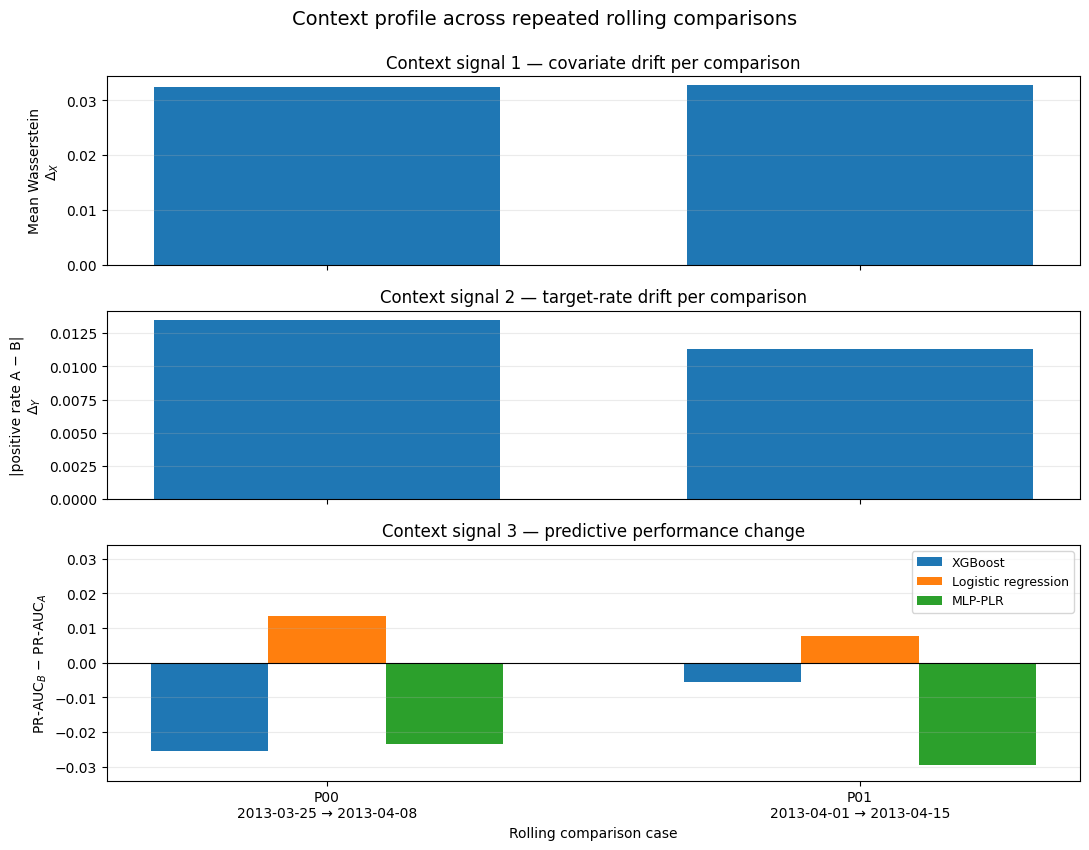

Saved: /content/drive/MyDrive/Thesis/Shoppers_workspace/data/results/combined/final_reporting_plots/02_stream_profile_xgboost_shap.png


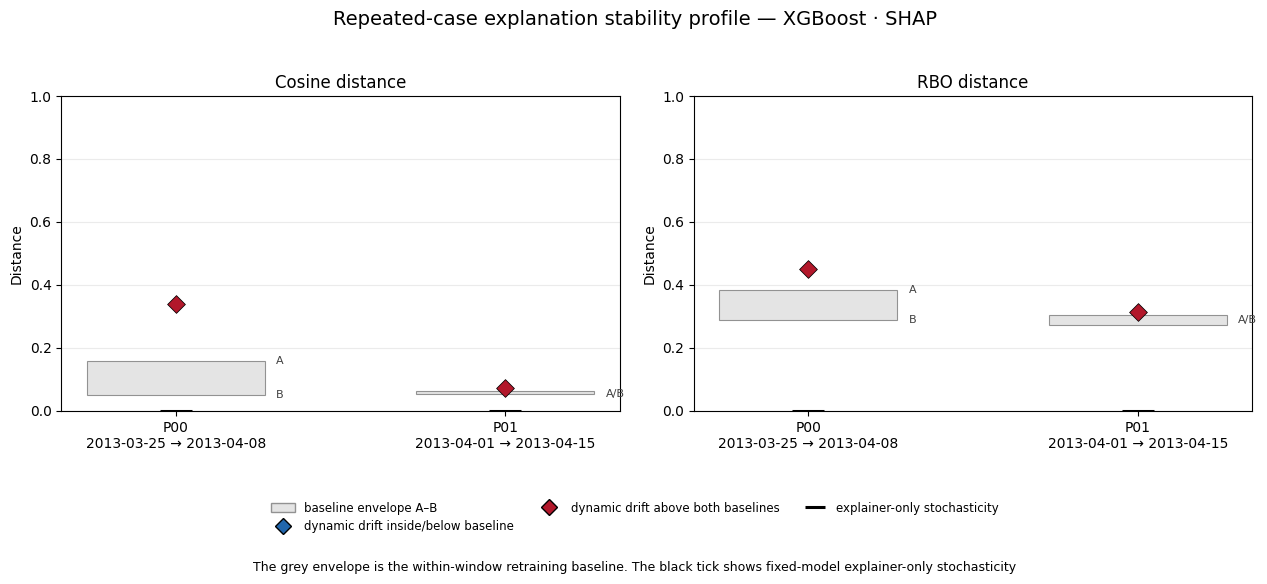

Saved: /content/drive/MyDrive/Thesis/Shoppers_workspace/data/results/combined/final_reporting_plots/02_stream_profile_xgboost_lime.png


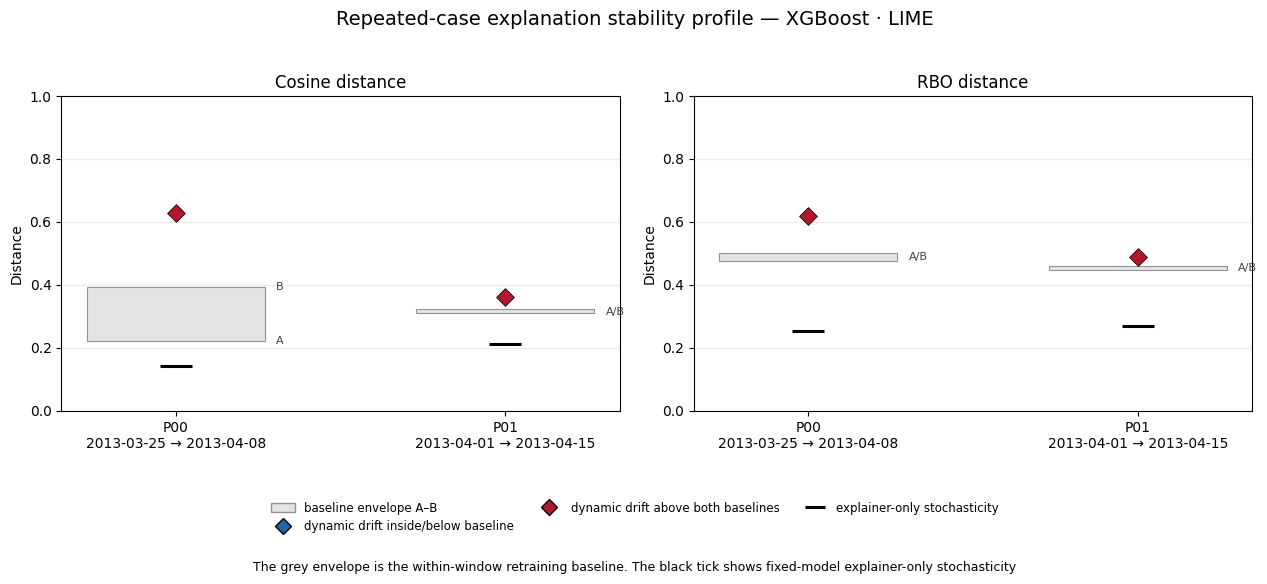

Saved: /content/drive/MyDrive/Thesis/Shoppers_workspace/data/results/combined/final_reporting_plots/02_stream_profile_mlp_plr_shap.png


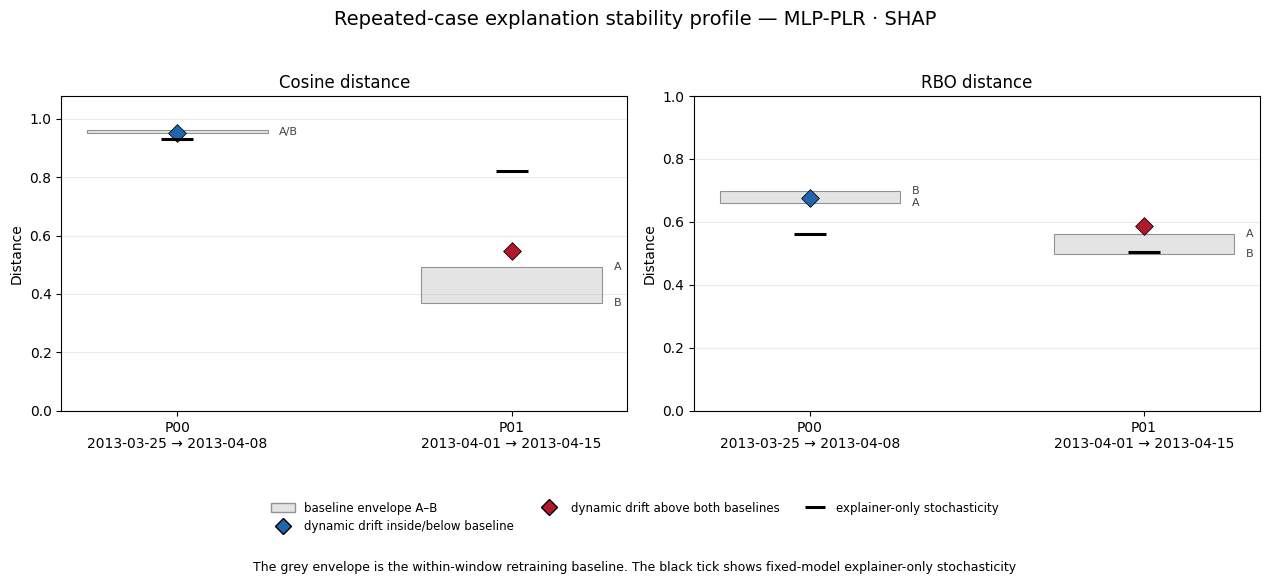

Saved: /content/drive/MyDrive/Thesis/Shoppers_workspace/data/results/combined/final_reporting_plots/02_stream_profile_mlp_plr_lime.png


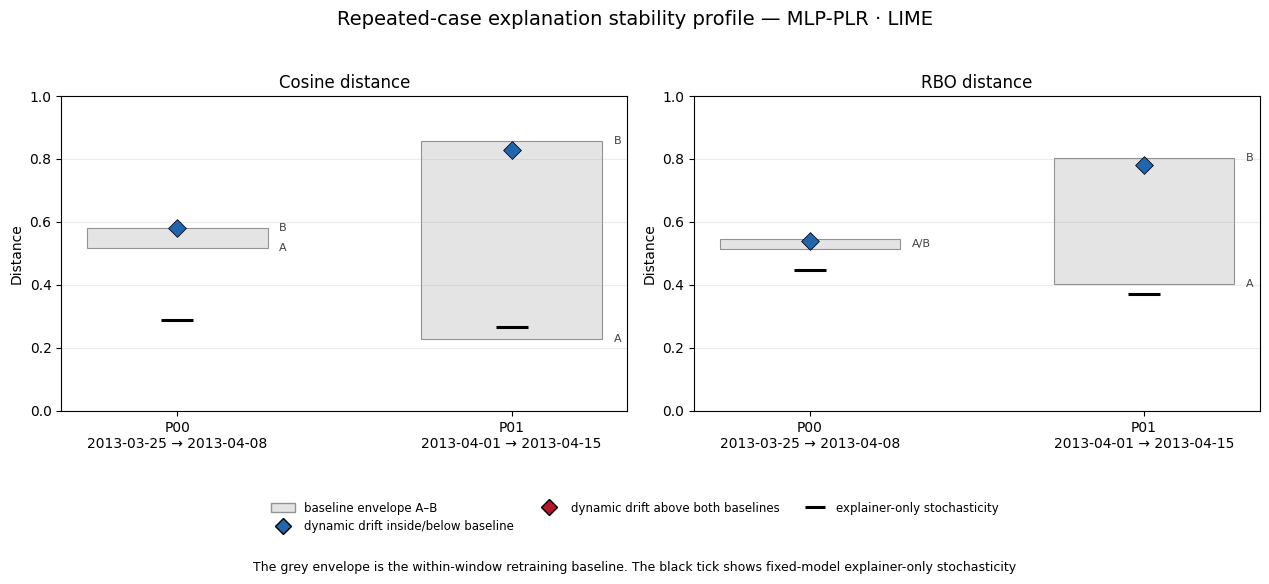

Saved: /content/drive/MyDrive/Thesis/Shoppers_workspace/data/results/combined/final_reporting_plots/04_global_shap_drift_cases.png


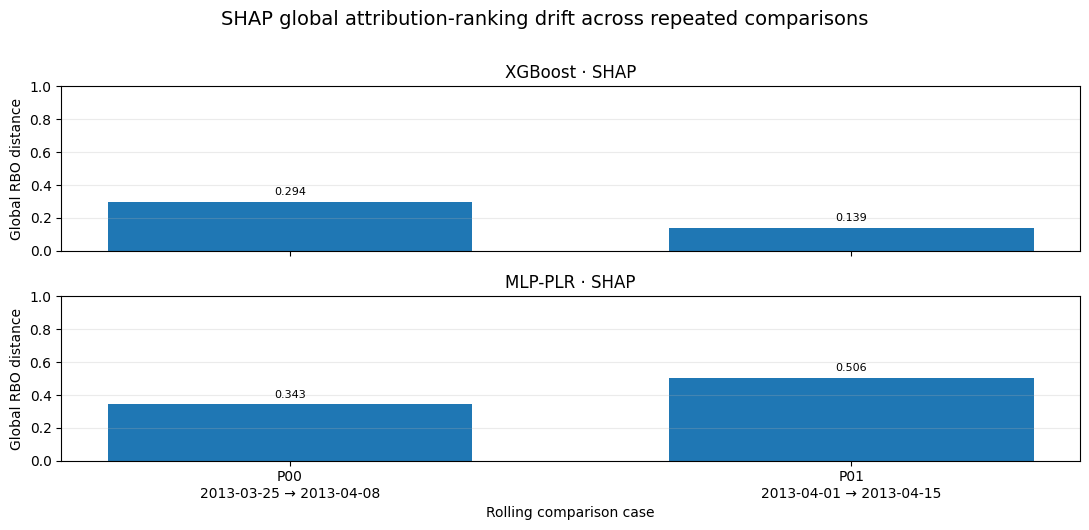

Saved: /content/drive/MyDrive/Thesis/Shoppers_workspace/data/results/combined/final_reporting_plots/05_logreg_transparent_reference.png


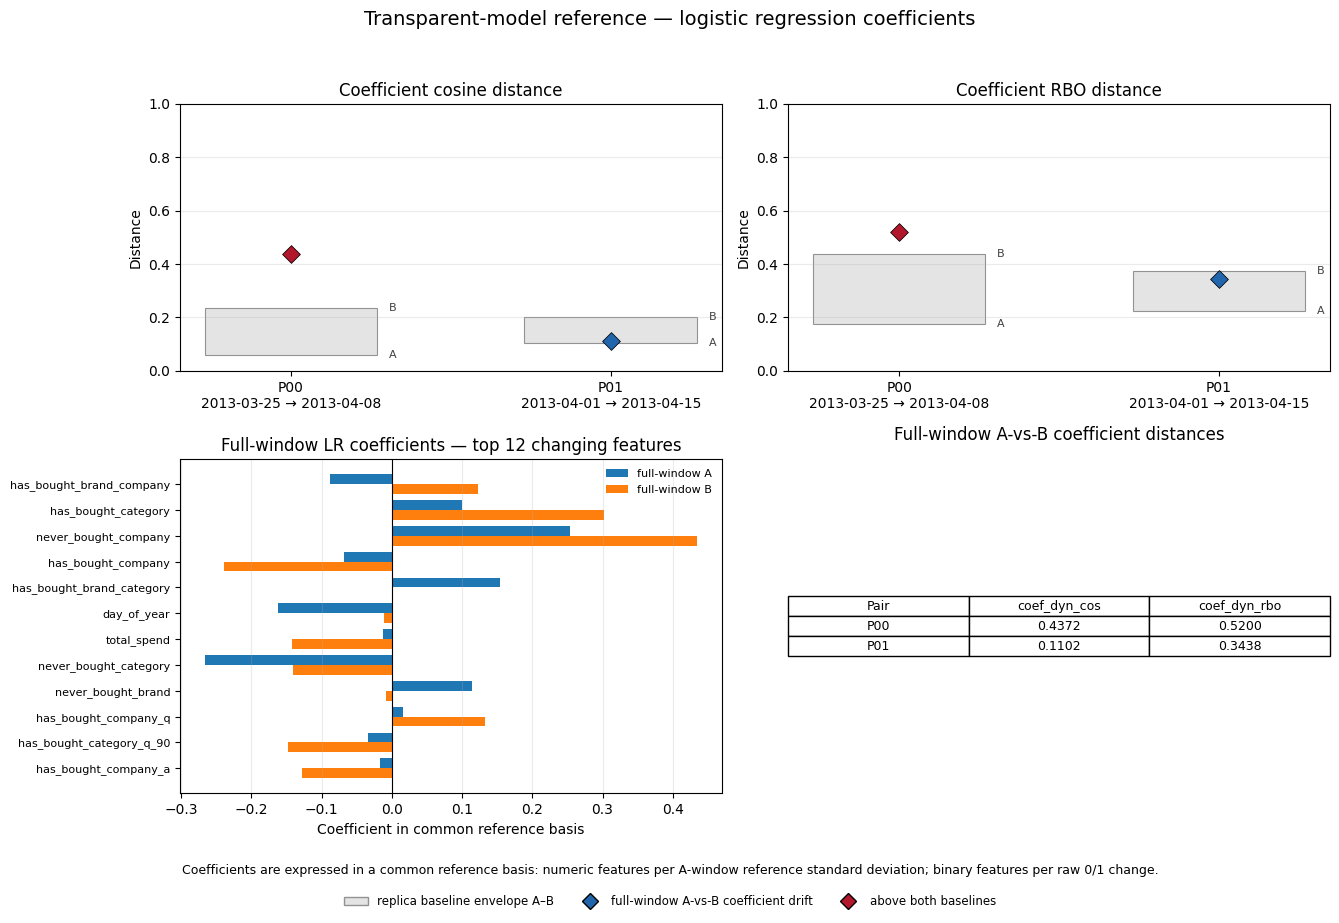


Done.
All final reporting plots saved in: /content/drive/MyDrive/Thesis/Shoppers_workspace/data/results/combined/final_reporting_plots


In [9]:
# ============================================================
# Final reporting plots — repeated diagnostic cases, polished
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path


# ─────────────────────────────────────────────────────────────
# Robust fallback loading
# ─────────────────────────────────────────────────────────────

try:
    combined_df
except NameError:
    WORKSPACE = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
    RESULTS_DIR_BASE = WORKSPACE / 'data' / 'results'
    COMBINED_DIR = RESULTS_DIR_BASE / 'combined'
    combined_df = pd.read_csv(COMBINED_DIR / 'drift_metrics_combined.csv')
else:
    if 'RESULTS_DIR_BASE' not in globals():
        WORKSPACE = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
        RESULTS_DIR_BASE = WORKSPACE / 'data' / 'results'
    if 'COMBINED_DIR' not in globals():
        COMBINED_DIR = RESULTS_DIR_BASE / 'combined'

FINAL_PLOT_DIR = COMBINED_DIR / 'final_reporting_plots'
FINAL_PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Final reporting plots will be saved to: {FINAL_PLOT_DIR}')


# ─────────────────────────────────────────────────────────────
# Labels and helpers
# ─────────────────────────────────────────────────────────────

MODEL_LABELS = {
    'xgboost': 'XGBoost',
    'logreg': 'Logistic regression',
    'mlp_plr': 'MLP-PLR',
}

EXPLAINER_LABELS = {
    'shap': 'SHAP',
    'lime': 'LIME',
    'coef': 'Coefficients',
}

POSTHOC_STREAM_ORDER = [
    ('xgboost', 'shap'),
    ('xgboost', 'lime'),
    ('mlp_plr', 'shap'),
    ('mlp_plr', 'lime'),
]


def _model_label(mt):
    return MODEL_LABELS.get(mt, str(mt))


def _explainer_label(expl):
    return EXPLAINER_LABELS.get(expl, str(expl))


def _stream_label(mt, expl):
    return f'{_model_label(mt)} · {_explainer_label(expl)}'


def _safe_save(fig, path, dpi=180):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'Saved: {path}')


def _comparison_info(df):
    cols = ['pair_id']
    for c in ['step_label_A', 'step_label_B', 'n_eval', 'n_flagged']:
        if c in df.columns:
            cols.append(c)

    info = (
        df[cols]
        .drop_duplicates('pair_id')
        .sort_values('pair_id')
        .reset_index(drop=True)
    )

    labels = []
    for _, row in info.iterrows():
        pid = int(row['pair_id'])
        if 'step_label_A' in info.columns and 'step_label_B' in info.columns:
            labels.append(f'P{pid:02d}\n{row["step_label_A"]} → {row["step_label_B"]}')
        else:
            labels.append(f'P{pid:02d}')
    info['case_label'] = labels
    return info


def _posthoc_streams(df):
    present = []
    for mt, expl in POSTHOC_STREAM_ORDER:
        sub = df[(df['model_type'] == mt) & (df['explainer'] == expl)]
        if sub.empty:
            continue
        if sub[['loc_cos', 'loc_rbo']].notna().any().any():
            present.append((mt, expl))

    existing = set(present)
    for mt, expl in (
        df[['model_type', 'explainer']]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    ):
        if expl == 'coef':
            continue
        if (mt, expl) in existing:
            continue
        sub = df[(df['model_type'] == mt) & (df['explainer'] == expl)]
        if sub[['loc_cos', 'loc_rbo']].notna().any().any():
            present.append((mt, expl))

    return present


def _aligned_values(sub, pair_ids, col):
    if col not in sub.columns:
        return np.full(len(pair_ids), np.nan, dtype=float)
    s = (
        sub.drop_duplicates('pair_id')
        .set_index('pair_id')
        .reindex(pair_ids)[col]
    )
    return pd.to_numeric(s, errors='coerce').to_numpy(dtype=float)


def _finite_max(*arrays, default=1.0):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        vals.extend(arr[np.isfinite(arr)].tolist())
    if not vals:
        return default
    return max(vals)


def _metric_ylim(metric_name, *arrays):
    max_val = _finite_max(*arrays, default=1.0)
    return 0.0, max(1.0, 1.12 * max_val)


def _symmetric_ylim(ax, values, min_abs=0.02):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    lim = min_abs if len(finite) == 0 else max(min_abs, float(np.max(np.abs(finite))) * 1.15)
    ax.set_ylim(-lim, lim)


def _dynamic_color(loc, base_A, base_B):
    if not np.isfinite(loc):
        return '0.45'
    if np.isfinite(base_A) and np.isfinite(base_B) and loc > max(base_A, base_B):
        return '#b2182b'
    return '#2166ac'


def _draw_baseline_envelope(ax, x, base_A, base_B, y_range,
                            width=0.54, min_height_frac=0.012):
    """
    Wide translucent A/B baseline envelope with direct boundary labels.
    """
    if not (np.isfinite(base_A) and np.isfinite(base_B)):
        return

    lo = min(base_A, base_B)
    hi = max(base_A, base_B)

    min_h = max(y_range * min_height_frac, 1e-4)
    rect_h = max(hi - lo, min_h)
    rect_y = lo if hi > lo else lo - rect_h / 2

    rect = Rectangle(
        (x - width / 2, rect_y),
        width,
        rect_h,
        facecolor='0.86',
        edgecolor='0.45',
        linewidth=0.8,
        alpha=0.75,
        zorder=1,
    )
    ax.add_patch(rect)

    close = abs(base_A - base_B) < 0.030 * max(y_range, 1e-8)
    x_text = x + width / 2 + 0.035

    if close:
        ax.text(
            x_text,
            0.5 * (base_A + base_B),
            'A/B',
            va='center',
            ha='left',
            fontsize=8,
            color='0.25',
            zorder=5,
        )
    else:
        ax.text(
            x_text,
            base_A,
            'A',
            va='center',
            ha='left',
            fontsize=8,
            color='0.25',
            zorder=5,
        )
        ax.text(
            x_text,
            base_B,
            'B',
            va='center',
            ha='left',
            fontsize=8,
            color='0.25',
            zorder=5,
        )


def _draw_profile_panel(ax, x, labels, loc, base_A, base_B, stoch,
                        metric_name, ylabel=None, title=None,
                        show_stoch=True):
    """
    Draw one profile panel:
    - grey rectangle: baseline envelope A/B;
    - small boundary labels: A and B;
    - diamond: dynamic drift;
    - black tick: explainer-only stochasticity.
    """
    ymin, ymax = _metric_ylim(metric_name, loc, base_A, base_B, stoch)
    y_range = ymax - ymin

    for i, xi in enumerate(x):
        _draw_baseline_envelope(
            ax=ax,
            x=xi,
            base_A=base_A[i],
            base_B=base_B[i],
            y_range=y_range,
        )

        ax.scatter(
            xi,
            loc[i],
            marker='D',
            s=82,
            color=_dynamic_color(loc[i], base_A[i], base_B[i]),
            edgecolor='black',
            linewidth=0.55,
            zorder=4,
        )

        if show_stoch and np.isfinite(stoch[i]):
            ax.scatter(
                xi,
                stoch[i],
                marker='_',
                s=520,
                color='black',
                linewidth=2.2,
                zorder=5,
            )

    ax.set_ylim(ymin, ymax)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, ha='center')
    ax.grid(axis='y', alpha=0.25)
    ax.axhline(0, color='black', linewidth=0.6)

    if title:
        ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)


# ─────────────────────────────────────────────────────────────
# 1. Context profile
# ─────────────────────────────────────────────────────────────

def plot_context_cases(df, save_path=None):
    if df is None or df.empty:
        print('combined_df is empty — skipping context plot.')
        return

    info = _comparison_info(df)
    pair_ids = info['pair_id'].tolist()
    labels = info['case_label'].tolist()
    x = np.arange(len(pair_ids))

    ctx = (
        df.groupby('pair_id', as_index=False)
        .agg(delta_X=('delta_X', 'mean'),
             delta_Y=('delta_Y', 'mean'))
        .set_index('pair_id')
        .reindex(pair_ids)
        .reset_index()
    )

    perf = df.drop_duplicates(['model_type', 'pair_id']).sort_values(['model_type', 'pair_id'])
    model_order = [m for m in ['xgboost', 'logreg', 'mlp_plr'] if m in perf['model_type'].unique()]
    model_order += [m for m in sorted(perf['model_type'].dropna().unique()) if m not in model_order]

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(11, 8.5),
        sharex=True,
        gridspec_kw={'height_ratios': [1.0, 1.0, 1.25]},
    )

    axes[0].bar(x, ctx['delta_X'].values, width=0.65)
    axes[0].set_title('Context signal 1 — covariate drift per comparison')
    axes[0].set_ylabel('Mean Wasserstein\n$\\Delta_X$')
    axes[0].set_ylim(bottom=0)
    axes[0].grid(axis='y', alpha=0.25)

    axes[1].bar(x, ctx['delta_Y'].values, width=0.65)
    axes[1].set_title('Context signal 2 — target-rate drift per comparison')
    axes[1].set_ylabel('|positive rate A − B|\n$\\Delta_Y$')
    axes[1].set_ylim(bottom=0)
    axes[1].grid(axis='y', alpha=0.25)

    ax = axes[2]
    width = min(0.22, 0.80 / max(len(model_order), 1))
    all_perf_vals = []

    for i, mt in enumerate(model_order):
        sub = perf[perf['model_type'] == mt]
        vals = _aligned_values(sub, pair_ids, 'delta_perf')
        all_perf_vals.extend(vals[np.isfinite(vals)].tolist())
        offset = (i - (len(model_order) - 1) / 2) * width
        ax.bar(x + offset, vals, width=width, label=_model_label(mt))

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Context signal 3 — predictive performance change')
    ax.set_ylabel('PR-AUC$_B$ − PR-AUC$_A$')
    ax.grid(axis='y', alpha=0.25)
    _symmetric_ylim(ax, np.array(all_perf_vals, dtype=float), min_abs=0.02)
    ax.legend(loc='best', fontsize=9)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(labels, rotation=0, ha='center')
    axes[-1].set_xlabel('Rolling comparison case')

    fig.suptitle('Context profile across repeated rolling comparisons', fontsize=14, y=0.995)
    fig.tight_layout()

    if save_path is None:
        save_path = FINAL_PLOT_DIR / '01_context_profile_cases.png'
    _safe_save(fig, save_path)
    plt.show()


# ─────────────────────────────────────────────────────────────
# 2. Per-stream explanation stability profiles
# ─────────────────────────────────────────────────────────────

def plot_stream_diagnostic_profile(df, mt, expl, save_path=None):
    sub = (
        df[(df['model_type'] == mt) & (df['explainer'] == expl)]
        .sort_values('pair_id')
        .copy()
    )

    if sub.empty:
        print(f'No data for {mt}/{expl} — skipping.')
        return

    info = _comparison_info(df)
    pair_ids = info['pair_id'].tolist()
    labels = info['case_label'].tolist()
    x = np.arange(len(pair_ids))

    loc_cos = _aligned_values(sub, pair_ids, 'loc_cos')
    base_cos_A = _aligned_values(sub, pair_ids, 'base_cos_A')
    base_cos_B = _aligned_values(sub, pair_ids, 'base_cos_B')
    stoch_cos = _aligned_values(sub, pair_ids, 'stoch_cos')

    loc_rbo = _aligned_values(sub, pair_ids, 'loc_rbo')
    base_rbo_A = _aligned_values(sub, pair_ids, 'base_rbo_A')
    base_rbo_B = _aligned_values(sub, pair_ids, 'base_rbo_B')
    stoch_rbo = _aligned_values(sub, pair_ids, 'stoch_rbo')

    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.9), sharex=True)

    _draw_profile_panel(
        axes[0], x, labels,
        loc=loc_cos,
        base_A=base_cos_A,
        base_B=base_cos_B,
        stoch=stoch_cos,
        metric_name='cos',
        ylabel='Distance',
        title='Cosine distance',
        show_stoch=True,
    )

    _draw_profile_panel(
        axes[1], x, labels,
        loc=loc_rbo,
        base_A=base_rbo_A,
        base_B=base_rbo_B,
        stoch=stoch_rbo,
        metric_name='rbo',
        ylabel='Distance',
        title='RBO distance',
        show_stoch=True,
    )

    # Manual legend.
    handles = [
        Rectangle((0, 0), 1, 1, facecolor='0.86', edgecolor='0.45', alpha=0.75,
                  label='baseline envelope A–B'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#2166ac',
                   markeredgecolor='black', markersize=8, label='dynamic drift inside/below baseline'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#b2182b',
                   markeredgecolor='black', markersize=8, label='dynamic drift above both baselines'),
        plt.Line2D([0], [0], marker='_', color='black', linestyle='None',
                   markersize=15, markeredgewidth=2.2, label='explainer-only stochasticity'),
    ]

    fig.legend(
        handles=handles,
        loc='lower center',
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.06),
        fontsize=8.5,
    )

    fig.suptitle(
        f'Repeated-case explanation stability profile — {_stream_label(mt, expl)}',
        fontsize=14,
        y=1.03,
    )

    fig.text(
        0.5,
        -0.115,
        'The grey envelope is the within-window retraining baseline. '
        'The black tick shows fixed-model explainer-only stochasticity',
        ha='center',
        fontsize=9,
    )

    fig.tight_layout(rect=[0, 0.10, 1, 1])

    if save_path is None:
        save_path = FINAL_PLOT_DIR / f'02_stream_profile_{mt}_{expl}.png'
    _safe_save(fig, save_path)
    plt.show()


# ─────────────────────────────────────────────────────────────
# 3. SHAP global drift
# ─────────────────────────────────────────────────────────────

def plot_global_shap_drift_cases(df, save_path=None):
    if 'global_rbo' not in df.columns:
        print('No global_rbo column found — skipping global SHAP plot.')
        return

    shap_df = (
        df[(df['explainer'] == 'shap') & df['global_rbo'].notna()]
        .copy()
        .sort_values(['model_type', 'pair_id'])
    )

    if shap_df.empty:
        print('No SHAP global drift rows found — skipping global SHAP plot.')
        return

    info = _comparison_info(df)
    pair_ids = info['pair_id'].tolist()
    labels = info['case_label'].tolist()
    x = np.arange(len(pair_ids))

    model_order = [m for m in ['xgboost', 'mlp_plr'] if m in shap_df['model_type'].unique()]
    model_order += [m for m in sorted(shap_df['model_type'].dropna().unique()) if m not in model_order]

    fig, axes = plt.subplots(
        len(model_order),
        1,
        figsize=(11, max(3.0, 2.6 * len(model_order))),
        sharex=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, mt in zip(axes, model_order):
        sub = shap_df[shap_df['model_type'] == mt]
        vals = _aligned_values(sub, pair_ids, 'global_rbo')

        ax.bar(x, vals, width=0.65)
        ax.set_title(f'{_model_label(mt)} · SHAP')
        ax.set_ylabel('Global RBO distance')
        ax.set_ylim(0, max(1.0, 1.10 * _finite_max(vals, default=1.0)))
        ax.grid(axis='y', alpha=0.25)

        if len(pair_ids) <= 5:
            for xi, val in zip(x, vals):
                if np.isfinite(val):
                    ax.annotate(
                        f'{val:.3f}',
                        xy=(xi, val),
                        xytext=(0, 5),
                        textcoords='offset points',
                        ha='center',
                        fontsize=8,
                    )

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(labels, rotation=0, ha='center')
    axes[-1].set_xlabel('Rolling comparison case')

    fig.suptitle(
        'SHAP global attribution-ranking drift across repeated comparisons',
        fontsize=14,
        y=1.01,
    )
    fig.tight_layout()

    if save_path is None:
        save_path = FINAL_PLOT_DIR / '04_global_shap_drift_cases.png'
    _safe_save(fig, save_path)
    plt.show()


# ─────────────────────────────────────────────────────────────
# 4. Logistic regression transparent reference
# ─────────────────────────────────────────────────────────────

def plot_lr_transparent_reference(df, feature_names, model_dir_base,
                                  top_k=12, save_path=None):
    lr = (
        df[(df['model_type'] == 'logreg') & (df['explainer'] == 'coef')]
        .copy()
        .sort_values('pair_id')
    )

    if lr.empty:
        print('No logistic-regression coefficient rows found — skipping LR reference plot.')
        return

    info = _comparison_info(df)
    pair_ids = info['pair_id'].tolist()
    labels = info['case_label'].tolist()
    x = np.arange(len(pair_ids))

    # Section A: baseline-vs-dynamic coefficient distance profile.
    coef_dyn_cos = _aligned_values(lr, pair_ids, 'coef_dyn_cos')
    coef_dyn_rbo = _aligned_values(lr, pair_ids, 'coef_dyn_rbo')
    base_cos_A = _aligned_values(lr, pair_ids, 'base_cos_A')
    base_cos_B = _aligned_values(lr, pair_ids, 'base_cos_B')
    base_rbo_A = _aligned_values(lr, pair_ids, 'base_rbo_A')
    base_rbo_B = _aligned_values(lr, pair_ids, 'base_rbo_B')

    fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0),
                             gridspec_kw={'height_ratios': [1.0, 1.25]})

    _draw_profile_panel(
        axes[0, 0], x, labels,
        loc=coef_dyn_cos,
        base_A=base_cos_A,
        base_B=base_cos_B,
        stoch=np.full(len(pair_ids), np.nan),
        metric_name='cos',
        ylabel='Distance',
        title='Coefficient cosine distance',
        show_stoch=False,
    )

    _draw_profile_panel(
        axes[0, 1], x, labels,
        loc=coef_dyn_rbo,
        base_A=base_rbo_A,
        base_B=base_rbo_B,
        stoch=np.full(len(pair_ids), np.nan),
        metric_name='rbo',
        ylabel='Distance',
        title='Coefficient RBO distance',
        show_stoch=False,
    )

    # Section B: full-window coefficient A-vs-B comparison.
    lr_dir_base = Path(model_dir_base) / 'logreg'
    available = []
    coef_A_list = []
    coef_B_list = []

    for pid in pair_ids:
        pair_dir = lr_dir_base / f'pair_{int(pid):02d}'
        a_path = pair_dir / 'coef_A_full_ref.npy'
        b_path = pair_dir / 'coef_B_full_ref.npy'
        if a_path.exists() and b_path.exists():
            available.append(pid)
            coef_A_list.append(np.load(a_path))
            coef_B_list.append(np.load(b_path))

    ax_bar = axes[1, 0]
    ax_table = axes[1, 1]

    if len(available) == 0:
        ax_bar.axis('off')
        ax_bar.text(
            0.5, 0.5,
            'Full-window LR reference coefficients not found.\n'
            'Rerun 02_training_replicas.ipynb with MODEL_TYPE="logreg".',
            ha='center',
            va='center',
        )
    else:
        coef_A_stack = np.vstack(coef_A_list)
        coef_B_stack = np.vstack(coef_B_list)
        mean_abs_gap = np.mean(np.abs(coef_A_stack - coef_B_stack), axis=0)
        top_idx = np.argsort(-mean_abs_gap)[:top_k]

        # Show average A/B coefficients across comparison cases for the most changing features.
        A_mean = coef_A_stack[:, top_idx].mean(axis=0)
        B_mean = coef_B_stack[:, top_idx].mean(axis=0)

        y = np.arange(len(top_idx))
        bar_h = 0.38

        ax_bar.barh(y - bar_h / 2, A_mean, height=bar_h, label='full-window A')
        ax_bar.barh(y + bar_h / 2, B_mean, height=bar_h, label='full-window B')
        ax_bar.axvline(0, color='black', linewidth=0.8)
        ax_bar.set_yticks(y)
        ax_bar.set_yticklabels([feature_names[j] for j in top_idx], fontsize=8)
        ax_bar.invert_yaxis()
        ax_bar.set_title(f'Full-window LR coefficients — top {top_k} changing features')
        ax_bar.set_xlabel('Coefficient in common reference basis')
        ax_bar.grid(axis='x', alpha=0.25)
        ax_bar.legend(frameon=False, fontsize=8)

    # Small numeric table with coefficient dynamic distances.
    ax_table.axis('off')
    table_cols = ['Pair', 'coef_dyn_cos', 'coef_dyn_rbo']
    table_data = []
    for pid, cos_v, rbo_v in zip(pair_ids, coef_dyn_cos, coef_dyn_rbo):
        table_data.append([
            f'P{int(pid):02d}',
            '-' if not np.isfinite(cos_v) else f'{cos_v:.4f}',
            '-' if not np.isfinite(rbo_v) else f'{rbo_v:.4f}',
        ])

    tab = ax_table.table(
        cellText=table_data,
        colLabels=table_cols,
        loc='center',
        cellLoc='center',
        colLoc='center',
    )
    tab.auto_set_font_size(False)
    tab.set_fontsize(9)
    tab.scale(1.0, 1.25)
    ax_table.set_title('Full-window A-vs-B coefficient distances', pad=14)

    handles = [
        Rectangle((0, 0), 1, 1, facecolor='0.86', edgecolor='0.45', alpha=0.75,
                  label='replica baseline envelope A–B'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#2166ac',
                   markeredgecolor='black', markersize=8, label='full-window A-vs-B coefficient drift'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#b2182b',
                   markeredgecolor='black', markersize=8, label='above both baselines'),
    ]

    fig.legend(
        handles=handles,
        loc='lower center',
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.015),
        fontsize=8.5,
    )

    fig.suptitle(
        'Transparent-model reference — logistic regression coefficients',
        fontsize=14,
        y=0.995,
    )

    fig.text(
        0.5,
        0.035,
        'Coefficients are expressed in a common reference basis: numeric features per A-window reference standard deviation; '
        'binary features per raw 0/1 change.',
        ha='center',
        fontsize=9,
    )

    fig.tight_layout(rect=[0, 0.06, 1, 0.97])

    if save_path is None:
        save_path = FINAL_PLOT_DIR / '05_logreg_transparent_reference.png'
    _safe_save(fig, save_path)
    plt.show()


# ─────────────────────────────────────────────────────────────
# Run all final reporting plots
# ─────────────────────────────────────────────────────────────

plot_context_cases(combined_df)

for mt, expl in _posthoc_streams(combined_df):
    plot_stream_diagnostic_profile(combined_df, mt, expl)

plot_global_shap_drift_cases(combined_df)
plot_lr_transparent_reference(combined_df, feature_names, MODEL_DIR_BASE)

print('\nDone.')
print(f'All final reporting plots saved in: {FINAL_PLOT_DIR}')